# This notebook reproduces following figures: Fig. 2.

Following network files were used to simulate the networks:
- nw_iall_recall_stim_disinh.py

In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt

## Helping functions 

In [2]:
N_exc, N_inh = 8000, 2000
N = N_exc + N_inh

cell_rows      = 100
exc_cell_cols  = 80
inh_cell_cols  = 20
scale          = 10 

engram_exc_ids = np.arange(0, 784)
engram_inh_ids = np.arange(0, 196)

stim_exc       = np.arange(0, 196)
engram_exc_rest= np.arange(0, 784)
non_engram_exc = np.arange(784, N_exc)

engram_inh     = N_exc + np.arange(98, 196)
non_engram_inh = N_exc + np.arange(196, 2000)

inh_engram_rng = (0,   196)
inh_non_rng    = (196, 2000)
exc_engram_rng = (0,   784)
exc_non_rng    = (784, 8000)

exc_square_h, exc_square_w = 28, 28
exc_r0, exc_c0 = 42, 36
inh_bar_h, inh_bar_w = 28, 7
inh_r0, inh_c0 = 42, 7

exc_layout = np.full((cell_rows, exc_cell_cols), -1, dtype=int)
exc_square_ids = engram_exc_ids.reshape(exc_square_h, exc_square_w, order='F')
exc_layout[exc_r0:exc_r0+exc_square_h, exc_c0:exc_c0+exc_square_w] = exc_square_ids
remaining_exc = np.setdiff1d(np.arange(N_exc), engram_exc_ids, assume_unique=True)
free_pos = np.argwhere(exc_layout == -1)
exc_layout[free_pos[:, 0], free_pos[:, 1]] = remaining_exc[:len(free_pos)]

inh_layout = np.full((cell_rows, inh_cell_cols), -1, dtype=int)
inh_global_ids    = N_exc + np.arange(N_inh)
engram_inh_global = N_exc + engram_inh_ids
inh_bar_ids = engram_inh_global.reshape(inh_bar_h, inh_bar_w)
inh_layout[inh_r0:inh_r0+inh_bar_h, inh_c0:inh_c0+inh_bar_w] = inh_bar_ids
remaining_inh = np.setdiff1d(inh_global_ids, engram_inh_global, assume_unique=True)
free_pos = np.argwhere(inh_layout == -1)
inh_layout[free_pos[:, 0], free_pos[:, 1]] = remaining_inh[:len(free_pos)]

layout_cells = np.hstack([exc_layout, inh_layout])
exc_width_pixels = exc_cell_cols * scale

In [3]:
def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)


def plot_group_mean_sd(ax, x, rates, color):
    mean = rates.mean(axis=0)
    ax.plot(x, mean, color=color, lw=2.8)


def population_rate_matrix(ids, times, neuron_ids, bins, bin_s):
    neuron_ids = np.asarray(neuron_ids)
    n_neurons  = len(neuron_ids)
    T          = len(bins) - 1
    id_to_row  = {nid: i for i, nid in enumerate(neuron_ids)}
    counts     = np.zeros((n_neurons, T))
    bin_idx    = np.digitize(times, bins) - 1
    valid      = (bin_idx >= 0) & (bin_idx < T)
    for nid, b in zip(ids[valid], bin_idx[valid]):
        r = id_to_row.get(nid)
        if r is not None:
            counts[r, b] += 1
    return counts / bin_s   # Hz


def mean_weight_for_block(pre_global, post_global, w,
                           pre_is_inh=False, post_is_inh=False,
                           pre_rng=None, post_rng=None):
    pre  = pre_global.copy()
    post = post_global.copy()
    if pre_is_inh:  pre  = pre  - N_exc
    if post_is_inh: post = post - N_exc
    lo_pre,  hi_pre  = pre_rng
    lo_post, hi_post = post_rng
    m = (pre >= lo_pre) & (pre < hi_pre) & (post >= lo_post) & (post < hi_post)
    return float(np.mean(w[m])) if np.any(m) else np.nan


def plot_heatmap(spike_file, t0, t1, vmax=100):
    """Activity heatmap for window [t0, t1] (seconds)."""
    spikes = np.loadtxt(spike_file)
    ids_all = spikes[:, 0].astype(int)
    times_all = spikes[:, 1]
    dt   = t1 - t0
    mask = (times_all >= t0) & (times_all < t1)
    counts = np.bincount(ids_all[mask], minlength=N)
    rates  = counts / dt
    activity_cells = rates[layout_cells]
    activity_map   = np.kron(activity_cells, np.ones((scale, scale)))
    fig, ax = plt.subplots(figsize=(3, 3))
    im = ax.imshow(activity_map, origin='lower', cmap='Greys',
                   interpolation='nearest', vmin=0, vmax=vmax)
    ax.axvline(exc_width_pixels - 0.5, color='k', lw=2)
    ax.set_xticks([]); ax.set_yticks([])
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label('Hz')
    plt.tight_layout()
    plt.show()


def plot_rates(spike_file, t_plot_start, t_plot_end, bin_ms, ylim=(1, 120)):
    """Exc and inh population rate plots for window [t_plot_start, t_plot_end]."""
    spikes = np.loadtxt(spike_file)
    ids   = spikes[:, 0].astype(int)
    times = spikes[:, 1]
    mask  = (times >= t_plot_start) & (times < t_plot_end)
    ids, times = ids[mask], times[mask]
    bins = np.arange(t_plot_start, t_plot_end + bin_ms, bin_ms)
    bc   = bins[:-1] + bin_ms / 2
    r_eng_exc = population_rate_matrix(ids, times, engram_exc_rest, bins, bin_ms)
    r_non_exc = population_rate_matrix(ids, times, non_engram_exc,  bins, bin_ms)
    r_eng_inh = population_rate_matrix(ids, times, engram_inh,       bins, bin_ms)
    r_non_inh = population_rate_matrix(ids, times, non_engram_inh,   bins, bin_ms)

    # exc
    fig, ax = plt.subplots(figsize=(3.25, 1.5))
    plot_group_mean_sd(ax, bc, r_eng_exc, 'red')
    plot_group_mean_sd(ax, bc, r_non_exc, 'black')
    ax.set_xlim(t_plot_start, t_plot_end)
    ax.set_ylim(*ylim); ax.set_yscale('log')
    ax.set_ylabel('Hz'); ax.set_xlabel('Time (s)')
    style_axis(ax)
    plt.tight_layout(pad=0.4)
    plt.show()

    # inh
    fig, ax = plt.subplots(figsize=(3.25, 1.5))
    plot_group_mean_sd(ax, bc, r_eng_inh, 'blue')
    plot_group_mean_sd(ax, bc, r_non_inh, 'black')
    ax.set_xlim(t_plot_start, t_plot_end)
    ax.set_ylim(*ylim); ax.set_yscale('log')
    ax.set_ylabel('Hz'); ax.set_xlabel('Time (s)')
    style_axis(ax)
    plt.tight_layout(pad=0.4)
    plt.show()


def plot_weights(out_dir, t_plot_start, t_plot_end, ylim=(1, 10)):
    """IE and II mean weight traces for window [t_plot_start, t_plot_end]."""
    def parse_t(path):
        return float(os.path.basename(path).replace('_weights_and_connectivity.npz', ''))
    npz_files = sorted(glob.glob(os.path.join(out_dir, '*_weights_and_connectivity.npz')))
    times, ie_p, ie_g, ii_p, ii_g = [], [], [], [], []
    for f in npz_files:
        t = parse_t(f)
        if not (t_plot_start <= t <= t_plot_end): continue
        d = np.load(f)
        pre_IE, post_IE, w_IE = d['pre_IE'],  d['post_IE'],  d['w_IE']
        pre_II, post_II, w_II = d['pre_II'],  d['post_II'],  d['w_II']
        times.append(t)
        ie_p.append(mean_weight_for_block(pre_IE, post_IE, w_IE,
                        pre_is_inh=True, post_is_inh=False,
                        pre_rng=inh_engram_rng, post_rng=exc_engram_rng))
        ie_g.append(mean_weight_for_block(pre_IE, post_IE, w_IE,
                        pre_is_inh=True, post_is_inh=False,
                        pre_rng=inh_non_rng, post_rng=exc_non_rng))
        ii_p.append(mean_weight_for_block(pre_II, post_II, w_II,
                        pre_is_inh=True, post_is_inh=True,
                        pre_rng=inh_engram_rng, post_rng=inh_engram_rng))
        ii_g.append(mean_weight_for_block(pre_II, post_II, w_II,
                        pre_is_inh=True, post_is_inh=True,
                        pre_rng=inh_non_rng, post_rng=inh_non_rng))
    times, ie_p, ie_g, ii_p, ii_g = [np.asarray(x) for x in (times,ie_p,ie_g,ii_p,ii_g)]

    # ie
    fig, ax = plt.subplots(figsize=(3.25, 1.5))
    ax.plot(times, ie_p, color='purple', lw=2.8)
    ax.plot(times, ie_g, color='green',  lw=2.8)
    ax.set_xlim(t_plot_start, t_plot_end)
    ax.set_ylim(*ylim); ax.set_yscale('log')
    ax.set_xlabel('Time'); style_axis(ax)
    plt.tight_layout(pad=0.4); plt.show()

    # ii
    fig, ax = plt.subplots(figsize=(3.25, 1.5))
    ax.plot(times, ii_p, color='purple', lw=2.8)
    ax.plot(times, ii_g, color='green',  lw=2.8)
    ax.set_xlim(t_plot_start, t_plot_end)
    ax.set_ylim(*ylim); ax.set_yscale('log')
    ax.set_xlabel('Time'); style_axis(ax)
    plt.tight_layout(pad=0.4); plt.show()

## Fig 2C: Pre-assembly, balanced state 

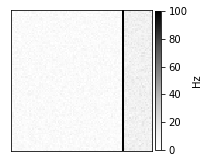

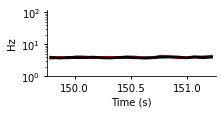

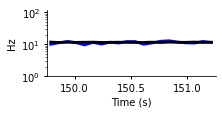

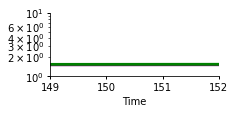

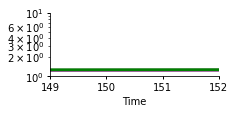

In [4]:
plot_heatmap(
    spike_file='data/fig2/42_3.0_10.0_28_603.0sec/spikes.txt',
    t0=150.0, t1=150.5
)

plot_rates(
    spike_file='data/fig2/42_3.0_10.0_28_603.0sec/spikes.txt',
    t_plot_start=149.75, t_plot_end=151.25,
    bin_ms=0.075
)

plot_weights(
    out_dir='data/fig2/weight_snapshots_fig_2',
    t_plot_start=149.0, t_plot_end=152.0
)

## Fig 2D: EI-assembly embedding

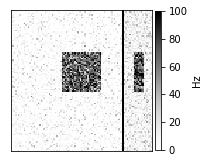

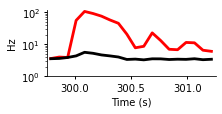

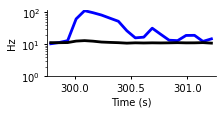

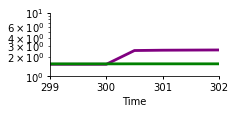

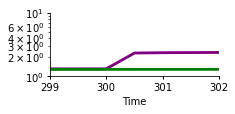

In [5]:
plot_heatmap(
    spike_file='data/fig2/42_3.0_10.0_28_603.0sec/spikes.txt',
    t0=300.0, t1=300.5
)

plot_rates(
    spike_file='data/fig2/42_3.0_10.0_28_603.0sec/spikes.txt',
    t_plot_start=299.75, t_plot_end=301.25,
    bin_ms=0.075
)

plot_weights(
    out_dir='data/fig2/weight_snapshots_fig_2',
    t_plot_start=299.0, t_plot_end=302.0
)

## Fig 2E: EI-assembly stabilization

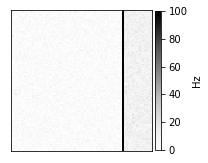

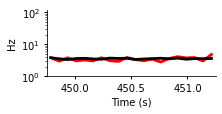

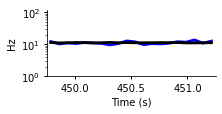

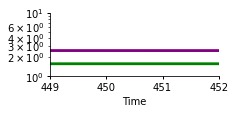

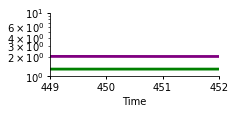

In [6]:
plot_heatmap(
    spike_file='data/fig2/42_3.0_10.0_28_603.0sec/spikes.txt',
    t0=450.0, t1=450.5
)

plot_rates(
    spike_file='data/fig2/42_3.0_10.0_28_603.0sec/spikes.txt',
    t_plot_start=449.75, t_plot_end=451.25,
    bin_ms=0.075
)

plot_weights(
    out_dir='data/fig2/weight_snapshots_fig_2',
    t_plot_start=449.0, t_plot_end=452.0
)

## Fig 2F: Recall through stimulation

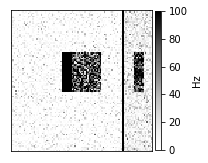

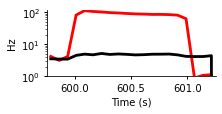

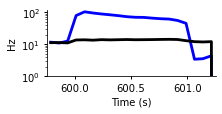

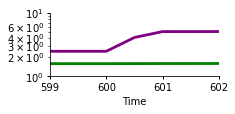

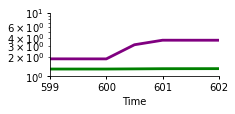

In [7]:
plot_heatmap(
    spike_file='data/fig2/42_3.0_10.0_28_603.0sec/spikes.txt',
    t0=600.0, t1=600.5
)

plot_rates(
    spike_file='data/fig2/42_3.0_10.0_28_603.0sec/spikes.txt',
    t_plot_start=599.75, t_plot_end=601.25,
    bin_ms=0.075
)

plot_weights(
    out_dir='data/fig2/weight_snapshots_fig_2',
    t_plot_start=599.0, t_plot_end=602.0
)

## Fig 2G: Recall through disinhibition

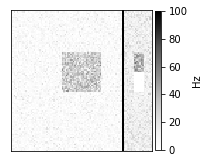

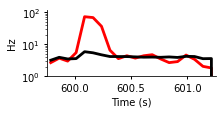

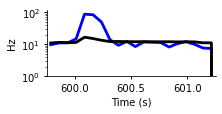

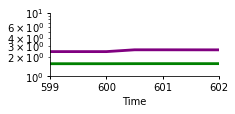

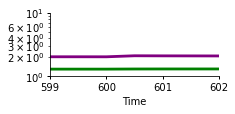

In [8]:
plot_heatmap(
    spike_file='data/fig2/42_3.0_10.0_14_603.0sec/spikes.txt',
    t0=600.0, t1=600.5
)

plot_rates(
    spike_file='data/fig2/42_3.0_10.0_14_603.0sec/spikes.txt',
    t_plot_start=599.75, t_plot_end=601.25,
    bin_ms=0.075
)

plot_weights(
    out_dir='data/fig2/inh_weight_snapshots_fig_2',
    t_plot_start=599.0, t_plot_end=602.0
)